# Birth parameters, common envelopes, and the DCO mass plane
**Author: Maryam Ahsan**

> **NOTE:** The work in this noteboook was inspired while working through [`tutorial_2_analysis_of_a_population_of_gravitational_wave_sources.ipynb`](https://github.com/FloorBroekgaarden/GROWL-catalog-public/blob/main/onboarding_growl/tutorial_2_analysis_of_a_population_of_gravitational_wave_sources.ipynb) as part of GROWL onboarding, which is why some blocks of code and conventions/asssumptions used here will be similar to the ones in tutorial 2.That is the notebook to be studied to understand the physics and working done here.
>
>AI was used to help write the code in [Section 2](#2-Load-compact-binaries-and-join-their-initial-conditions) block 2, and to handle plots with multiple graphs.

This is companion investigation to GROWL Notebook 2, using the **same** van Son et al. COMPAS weighted HDF5 file.

In this notebook we try to explore two questions: **Which initial binaries produce BBH, BH–NS, or NS–NS double compact objects (DCOs)?** And **how does their common-envelope history differ?** We then compare the masses of the final compact objects.

The analysis follows the `SEED` from `BSE_System_Parameters` to `BSE_Double_Compact_Objects` in the weighted COMPAS output used in GROWL tutorial 2. Weights account for the simulation's sampling strategy; they do not account for cosmic star formation, metallicity history, or observational selection.

In [68]:
from pathlib import Path
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, ListedColormap, BoundaryNorm
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D

DATA_PATH = Path(r"E:/GitHub/Data/COMPAS_Output_wWeights.h5") 
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .18})


## 1. Load the compact-object catalogue and its birth conditions

In [69]:
with h5py.File(DATA_PATH, "r") as f:
    for group_name in ("BSE_System_Parameters", "BSE_Double_Compact_Objects", "BSE_RLOF"):
        group = f[group_name]
        print(f"\n{group_name}: {len(group['SEED']):,} rows")
        print("  " + ", ".join(group.keys()))



BSE_System_Parameters: 10,000,000 rows
  Mass@ZAMS(1), Mass@ZAMS(2), Metallicity@ZAMS(1), SEED, Stellar_Type@ZAMS(1), Stellar_Type@ZAMS(2)

BSE_Double_Compact_Objects: 2,523,122 rows
  CE_Event_Counter, Coalescence_Time, Immediate_RLOF>CE, MT_Donor_Hist(1), MT_Donor_Hist(2), Mass(1), Mass(2), Merges_Hubble_Time, Metallicity@ZAMS(1), Optimistic_CE, SEED, Stellar_Type(1), Stellar_Type(2), Time, mixture_weight

BSE_RLOF: 31,878,423 rows
  CEE>MT, Eccentricity<MT, Eccentricity>MT, MT_Event_Counter, Mass(1)<MT, Mass(1)>MT, Mass(2)<MT, Mass(2)>MT, RLOF(1)>MT, RLOF(2)>MT, SEED


In [70]:
birth_cols = {
        "M1_zams": "Mass@ZAMS(1)",
        "M2_zams": "Mass@ZAMS(2)",
        "Z_zams": "Metallicity@ZAMS(1)",
    }

print("Birth columns selected:", birth_cols)

Birth columns selected: {'M1_zams': 'Mass@ZAMS(1)', 'M2_zams': 'Mass@ZAMS(2)', 'Z_zams': 'Metallicity@ZAMS(1)'}


## 2. Load compact binaries and join their initial conditions

The `(1)` and `(2)` DCO masses follow **stellar lineage**, whereas the plot uses sorted final compact-object masses `m1 >= m2`. For initial `q`, the **ZAMS masses** are used. Birth parameters only read for matching seeds in chunks so the ten-million-row birth table does not become an enormous DataFrame. An inner join drops DCOs without a matching birth row and reports the count.

In [71]:
# These columns contain outcomes, CE counts, and the mixture weights.
DCO_COLS = ["SEED", "Mass(1)", "Mass(2)", "Stellar_Type(1)", "Stellar_Type(2)",
            "Merges_Hubble_Time", "CE_Event_Counter", "mixture_weight"]

with h5py.File(DATA_PATH, "r") as f:
    g = f["BSE_Double_Compact_Objects"]

    # c: g[c][()] is a dictionary comprehension that creates a dictionary where the keys are the
    # column names in DCO_COLS and the values are the corresponding datasets read from the HDF5 file.
    # The [()] syntax is used to read the entire dataset into memory as a numpy array.
    dco = pd.DataFrame({c: g[c][()] for c in DCO_COLS})

# renaming columns for clarity and consistency
dco = dco.rename(columns={"Mass(1)":"remnant1", "Mass(2)":"remnant2",
                          "Stellar_Type(1)":"type1", "Stellar_Type(2)":"type2",
                          "Merges_Hubble_Time":"merges", "CE_Event_Counter":"n_CE",
                          "mixture_weight":"w"})


# ordering the remnant masses so that m1 >= m2, to stay consistent with tutorial_2
dco["m1"] = np.maximum(dco.remnant1, dco.remnant2)
dco["m2"] = np.minimum(dco.remnant1, dco.remnant2)

# creating a new column "kind" to store type label
dco["kind"] = np.select([(dco.type1.eq(14) & dco.type2.eq(14)), (dco.type1.eq(14) ^ dco.type2.eq(14)), (dco.type1.eq(13) & dco.type2.eq(13))],
                        ["BBH", "BH–NS", "NS–NS"],
                        default="other")

print(dco.groupby(["kind", "merges"], dropna=False).agg(rows=("SEED","size"), weight=("w","sum")))


                 rows         weight
kind  merges                        
BBH   0        632826  102778.217079
      1       1640550   14911.176778
BH–NS 0         51737    9396.196333
      1        192673    2918.325499
NS–NS 0          3414   12708.927155
      1          1922    6507.631762


In [72]:
# The DCO table contains one SEED per double compact object. Use these IDs
# to find the same binaries in the larger table of initial system parameters.
seeds_to_keep = pd.Index(dco.SEED)

# Store matching chunks here. This avoids loading the entire birth table
# into a DataFrame at once.
parts = []

with h5py.File(DATA_PATH, "r") as f:
    g = f["BSE_System_Parameters"]
    n_birth = len(g["SEED"])

    # Read 250,000 birth records at a time. The final chunk may be smaller.
    for start in range(0, n_birth, 250_000):
        end = min(start + 250_000, n_birth)
        seed_chunk = g["SEED"][start:end]

        # get_indexer returns -1 when a birth SEED is absent from the DCO table.
        # Keep birth systems that became a BBH, BH–NS, or NS–NS.
        matched = seeds_to_keep.get_indexer(seed_chunk) >= 0

        if matched.any():
            # Apply the same mask to SEED and every birth parameter so each
            # resulting row still describes one initial binary.
            block = {"SEED": seed_chunk[matched]}
        
            for short_name, dataset_name in birth_cols.items():
                block[short_name] = g[dataset_name][start:end][matched]
            parts.append(pd.DataFrame(block))


# Combine the matching birth records. Each DCO should have one birth record.
birth = pd.concat(parts, ignore_index=True)
assert birth.SEED.is_unique, "Duplicate birth records require inspection."

# Match each DCO's final properties to its initial masses and metallicity.
# validate checks that the join is one-to-one. The assertion below catches
# birth records missing from the inner join.
pop = dco.merge(birth, on="SEED", how="inner", validate="one_to_one")
print(f"Matched {len(pop):,} / {len(dco):,} DCOs to their birth records.")
assert len(pop) == len(dco), "Some DCOs have no birth conditions."

# Check the birth quantities before calculating ratios or plotting them.
assert np.isfinite(pop[["M1_zams", "M2_zams", "Z_zams"]]).all().all()
assert (pop[["M1_zams", "M2_zams", "Z_zams"]] > 0).all().all()

# Get initial mass ratio
pop["q_zams"] = np.minimum(pop.M1_zams, pop.M2_zams) / np.maximum(pop.M1_zams, pop.M2_zams)
assert pop.q_zams.between(0, 1, inclusive="right").all()

# Group CE event counts for plotting.
pop["CE_group"] = np.select([pop.n_CE.eq(0), pop.n_CE.eq(1), pop.n_CE.ge(2)],
                             ["0 CE", "1 CE", "2+ CE"], default="unknown")
assert pop.CE_group.ne("unknown").all()


# Create a summery of DCOs
ce_summary = pop.groupby(["kind", "merges", "CE_group"]).agg(rows=("SEED", "size"), weight=("w", "sum"))

ce_summary["weighted_percentage"] = (100 * ce_summary["weight"]/ce_summary.groupby(level=["kind", "merges"])["weight"].transform("sum"))

print(ce_summary.to_string(float_format=lambda value: f"{value:.2f}"))

Matched 2,523,122 / 2,523,122 DCOs to their birth records.
                          rows   weight  weighted_percentage
kind  merges CE_group                                       
BBH   0      0 CE       527197 98099.03                95.45
             1 CE       104670  4599.93                 4.48
             2+ CE         959    79.26                 0.08
      1      0 CE       452787  4106.44                27.54
             1 CE      1180083 10520.02                70.55
             2+ CE        7680   284.72                 1.91
BH–NS 0      0 CE        33763  5720.38                60.88
             1 CE        17705  3654.24                38.89
             2+ CE         269    21.58                 0.23
      1      0 CE         7709   234.27                 8.03
             1 CE       179705  2449.25                83.93
             2+ CE        5259   234.81                 8.05
NS–NS 0      0 CE          128   351.57                 2.77
             1 CE         

## 3. What initial conditions do the different DCOs have?

In [73]:
TYPES = ["BBH", "BH–NS", "NS–NS"]
TYPE_COLORS = {"BBH": "#24a2ab", "BH–NS": "#df853e", "NS–NS": "#a74787"}

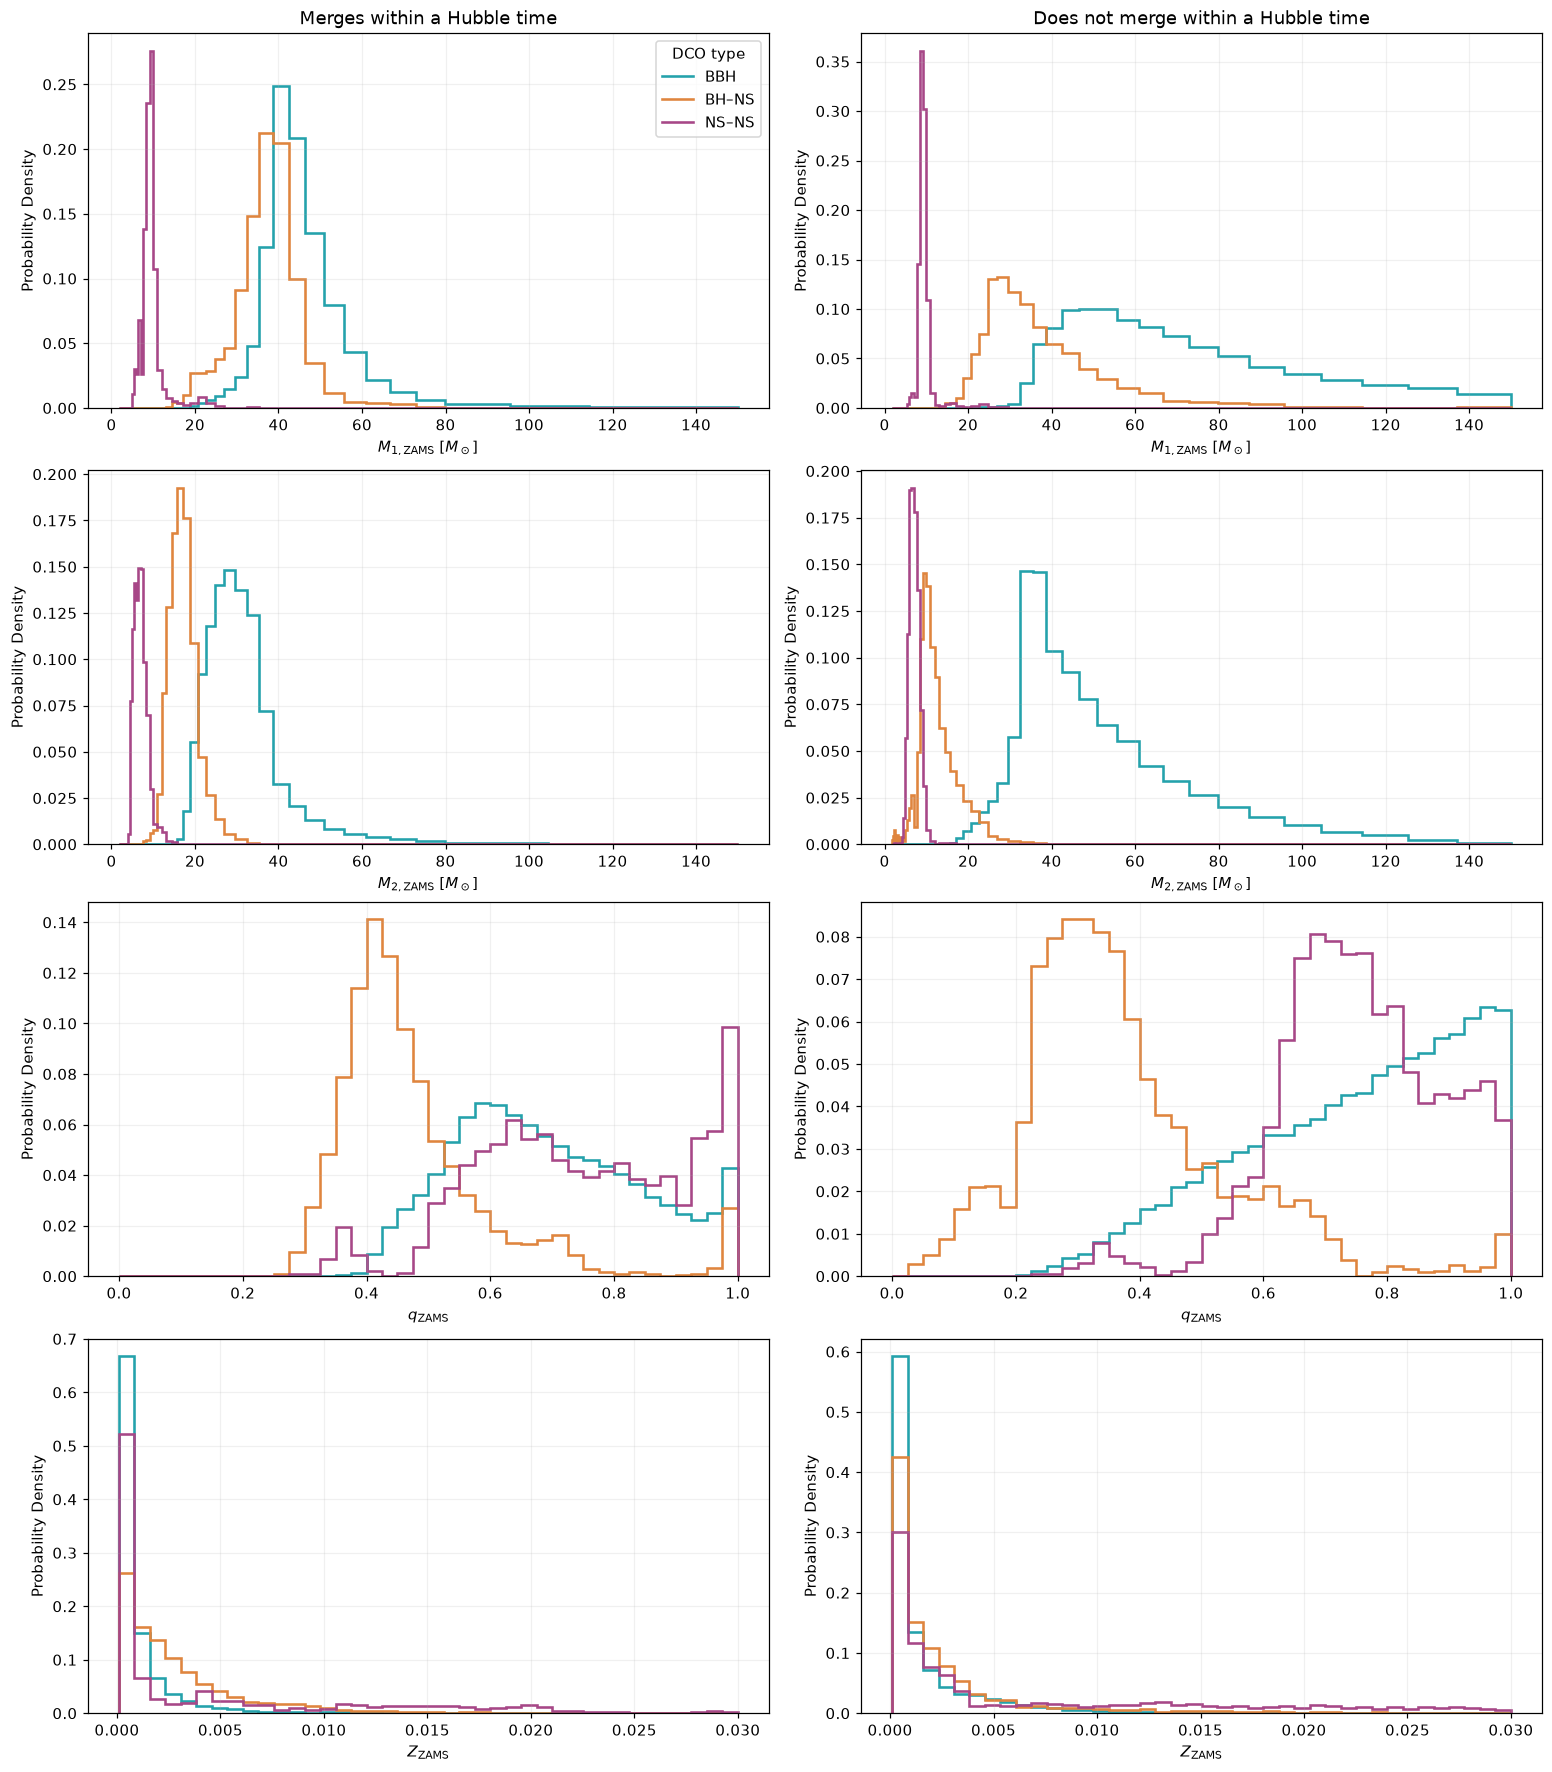

In [74]:
mass_lo = float(pop[["M1_zams", "M2_zams"]].min().min())
mass_hi = float(pop[["M1_zams", "M2_zams"]].max().max())

mass_edges = np.geomspace(mass_lo, mass_hi, 50)
q_edges = np.linspace(0, 1, 41)
Z_edges = np.linspace(pop.Z_zams.min(), pop.Z_zams.max(), 41)

variables = [("M1_zams", mass_edges, r"$M_{1,\rm ZAMS}$ [$M_\odot$]"),
             ("M2_zams", mass_edges, r"$M_{2,\rm ZAMS}$ [$M_\odot$]"),
             ("q_zams", q_edges, r"$q_{\rm ZAMS}$"),
             ("Z_zams", Z_edges, r"$Z_{\rm ZAMS}$")]

fig, axes = plt.subplots(4, 2, figsize=(14, 16), constrained_layout=True)

for col, status in enumerate([1, 0]):
    for row, (field, edges, xlabel) in enumerate(variables):
        ax = axes[row, col]
        for kind in TYPES:
            group = pop.loc[(pop.merges == status) & (pop.kind == kind)]
            counts, _ = np.histogram(group[field], bins=edges, weights=group.w, density=True)
            if counts.sum() > 0:
                ax.stairs(counts / counts.sum(), edges, color=TYPE_COLORS[kind],
                          lw=1.7, label=kind)
        #if row < 2:
            #ax.set_xscale("log")  # masses span a wide range; ticks still show masses
        if row == 3:
            ax.ticklabel_format(axis="x", style="plain", useOffset=False)
            ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
        ax.set(xlabel=xlabel, ylabel="Probability Density")
        if row == 0:
            ax.set_title("Merges within a Hubble time" if status else
                         "Does not merge within a Hubble time")
axes[0, 0].legend(title="DCO type")
plt.show()

## 4. Which pairs of initial masses produce each DCO type?

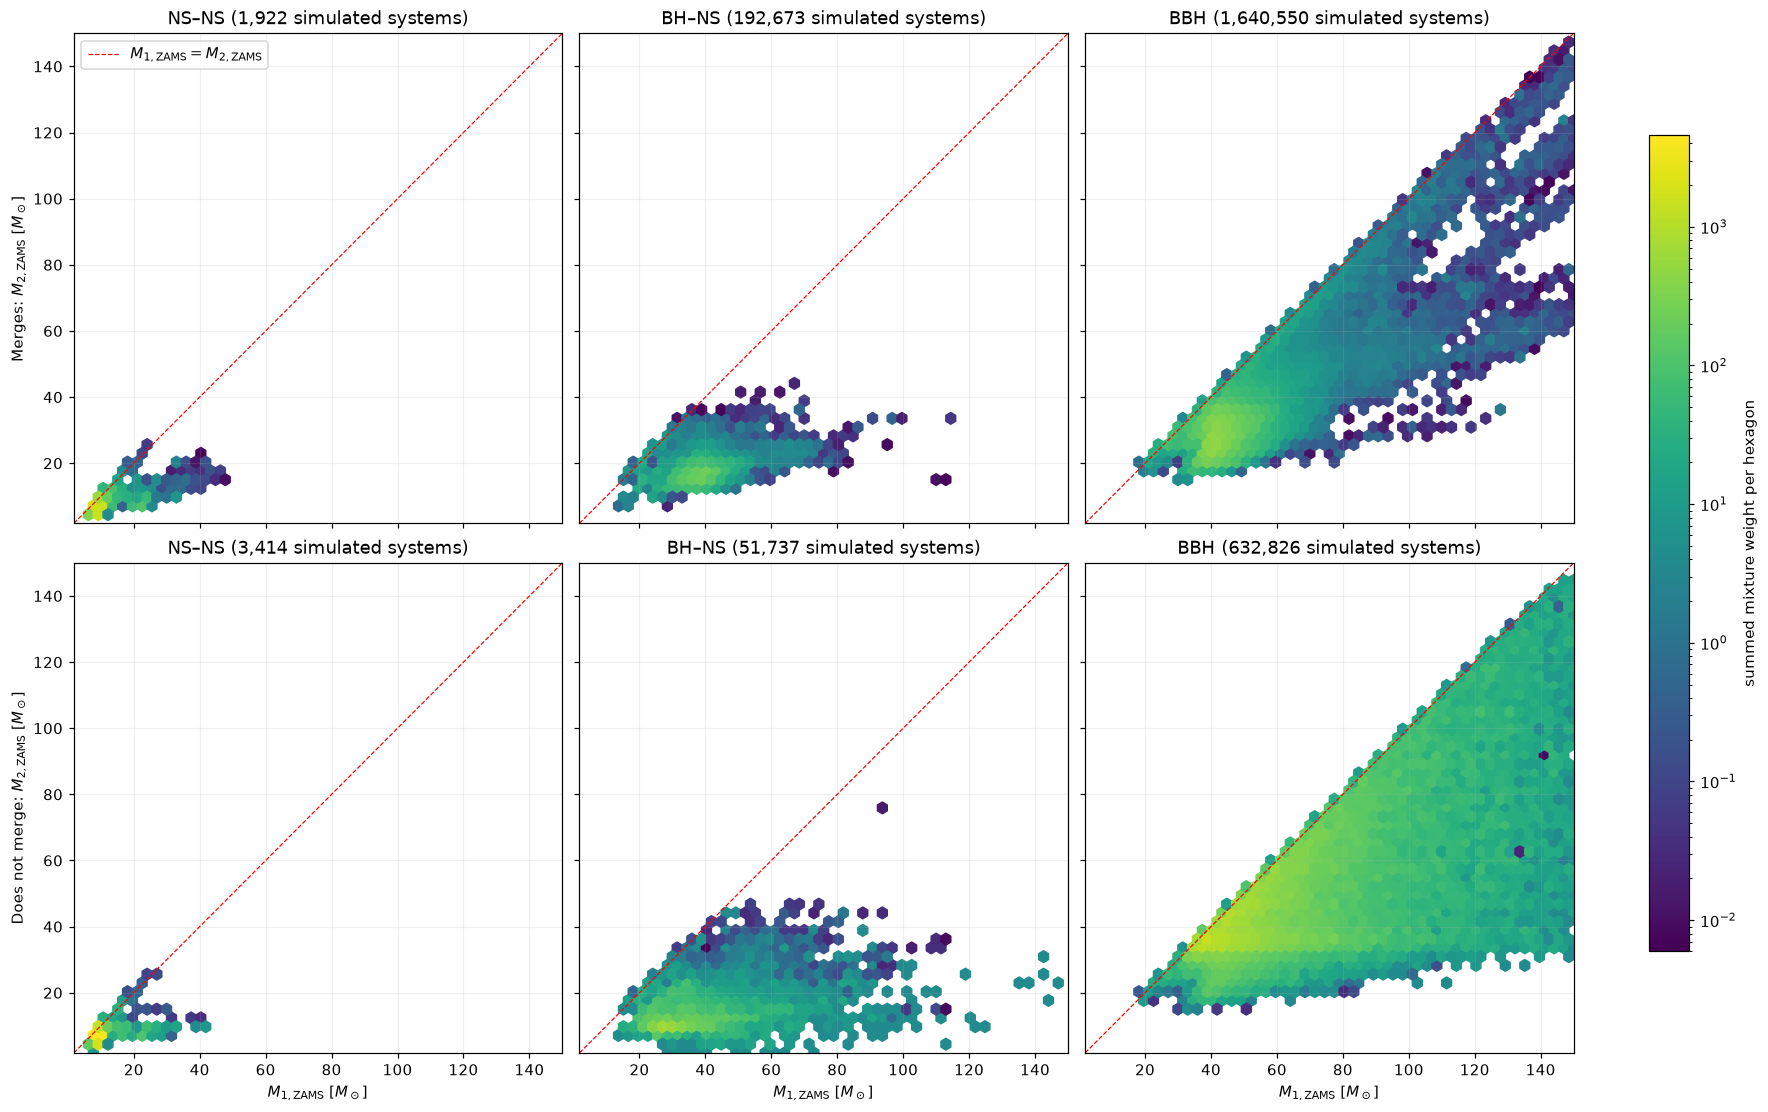

In [75]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharex=True, sharey=True,
                        constrained_layout=True)

hexes = []

for row, status in enumerate([1, 0]):
    for col, kind in enumerate(["NS–NS", "BH–NS", "BBH"]):
        ax = axes[row, col]
        group = pop.loc[(pop.merges == status) & (pop.kind == kind)]

        if group.empty:
            ax.set_title(f"{kind}: no systems")
            continue

        h = ax.hexbin(group.M1_zams, group.M2_zams, C=group.w, reduce_C_function=np.sum, 
                      gridsize=50, mincnt=1, extent=(mass_lo, mass_hi, mass_lo, mass_hi),
                      cmap="viridis")
        hexes.append(h)

        ax.plot([mass_lo, mass_hi], [mass_lo, mass_hi], "--", c="red", lw=0.8,
                 label = r"$M_{1,\rm ZAMS} = M_{2,\rm ZAMS}$")
        ax.set(xlim=(mass_lo, mass_hi), ylim=(mass_lo, mass_hi),
            title=f"{kind} ({len(group):,} simulated systems)")

    axes[row, 0].set_ylabel(("Merges: " if status else "Does not merge: ") + r"$M_{2,\rm ZAMS}$ [$M_\odot$]")

axes[0,0].legend()

for ax in axes[-1]:
    ax.set_xlabel(r"$M_{1,\rm ZAMS}$ [$M_\odot$]")

positive = np.concatenate([np.asarray(h.get_array())[np.asarray(h.get_array()) > 0]
                           for h in hexes])
common_norm = LogNorm(vmin=positive.min(), vmax=positive.max())

for h in hexes:
    h.set_norm(common_norm)

fig.colorbar(hexes[0], ax=axes, shrink=0.8, 
             label="summed mixture weight per hexagon")
plt.show()

## 5. Does common-envelope history differ between merging and nonmerging DCOs?

                          rows    weight  percent_within_status
kind  merges CE_group                                          
BBH   1      0 CE       452787   4106.44                  27.54
             1 CE      1180083  10520.02                  70.55
             2+ CE        7680    284.72                   1.91
      0      0 CE       527197  98099.03                  95.45
             1 CE       104670   4599.93                   4.48
             2+ CE         959     79.26                   0.08
BH–NS 1      0 CE         7709    234.27                   8.03
             1 CE       179705   2449.25                  83.93
             2+ CE        5259    234.81                   8.05
      0      0 CE        33763   5720.38                  60.88
             1 CE        17705   3654.24                  38.89
             2+ CE         269     21.58                   0.23
NS–NS 1      0 CE          120    244.37                   3.76
             1 CE         1802   6263.26

C:\Users\marya\AppData\Local\Temp\ipykernel_360\3846231532.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  group = ce_table.loc[(kind, status)].reindex(CE_CATEGORIES)
C:\Users\marya\AppData\Local\Temp\ipykernel_360\3846231532.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  group = ce_table.loc[(kind, status)].reindex(CE_CATEGORIES)
C:\Users\marya\AppData\Local\Temp\ipykernel_360\3846231532.py:15: PerformanceWarning: indexing past lexsort depth may impact performance.
  group = ce_table.loc[(kind, status)].reindex(CE_CATEGORIES)


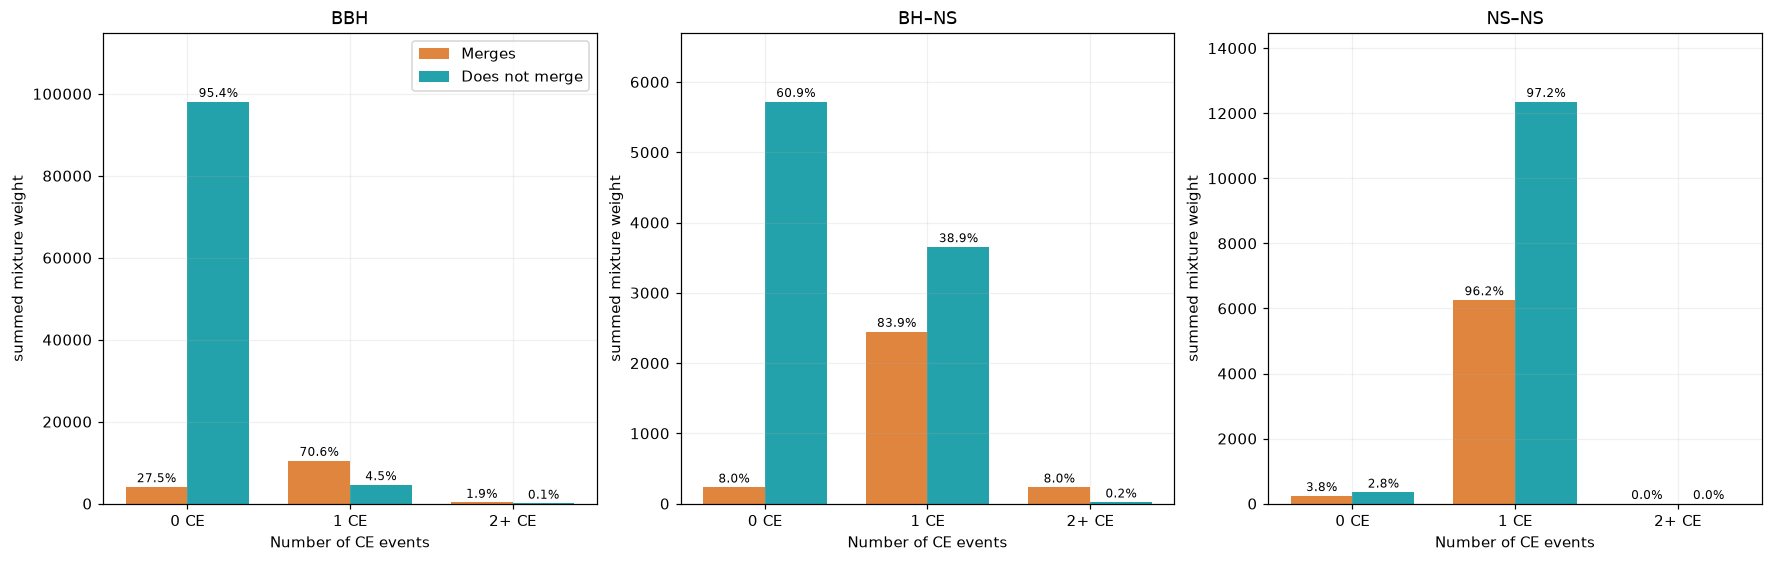

In [76]:
CE_CATEGORIES = ["0 CE", "1 CE", "2+ CE"]
index = pd.MultiIndex.from_product([TYPES, [1, 0], CE_CATEGORIES], names=["kind", "merges", "CE_group"])

ce_table = pop.groupby(["kind", "merges", "CE_group"]).agg(rows=("SEED", "size"), weight=("w", "sum")).reindex(index, fill_value=0)
ce_table["percent_within_status"] = (100 * ce_table.weight / ce_table.groupby(level=[0, 1]).weight.transform("sum"))

print(ce_table.round(2))

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)
x = np.arange(3)

for ax, kind in zip(axes, TYPES):
    for status, shift, color, label in [(1, -.19, "#df853e", "Merges"),
                                        (0, +.19, "#24a2ab", "Does not merge")]:
        group = ce_table.loc[(kind, status)].reindex(CE_CATEGORIES)
        bars = ax.bar(x + shift, group.weight.to_numpy(), width=.38,
                      color=color, label=label)
        
        for bar, pct in zip(bars, group.percent_within_status):
            ax.annotate(f"{pct:.1f}%", (bar.get_x() + bar.get_width()/2, bar.get_height()),
                        xytext=(0, 3), textcoords="offset points", ha="center", fontsize=8)
   
    ax.set(xticks=x, xticklabels=CE_CATEGORIES, xlabel="Number of CE events",
           ylabel="summed mixture weight", title=kind)
    ax.margins(y=.17)

axes[0].legend()

plt.show()

### Birth $q$ versus initial $Z$ for merging BBHs, separated by CE count

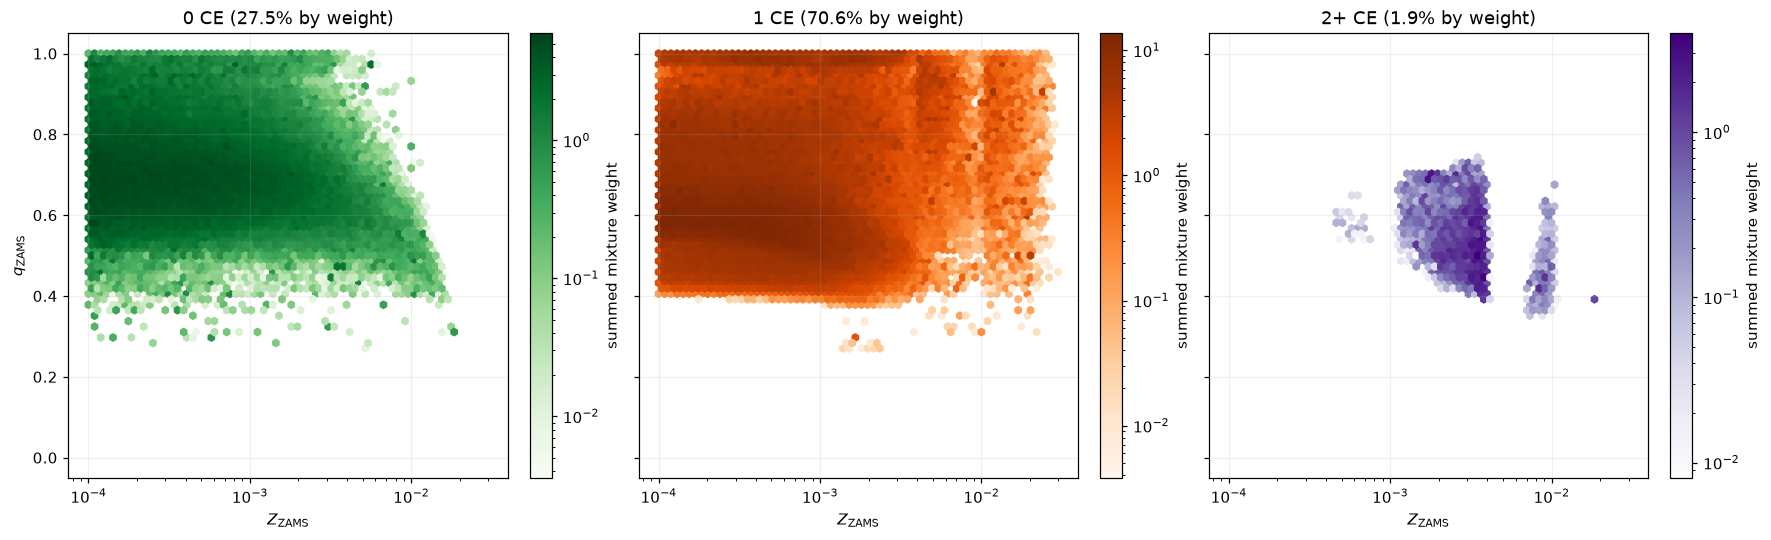

In [77]:
merging_bbh = pop.loc[(pop.kind == "BBH") & (pop.merges == 1)].copy()
Z_lim = (float(merging_bbh.Z_zams.min()), float(merging_bbh.Z_zams.max()))
log_Z_lim = tuple(np.log10(Z_lim))

channel_styles = [("0 CE", "Greens"), ("1 CE", "Oranges"), ("2+ CE", "Purples")]
Z_lim = (float(merging_bbh.Z_zams.min()), float(merging_bbh.Z_zams.max()))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True,
                         constrained_layout=True)
for ax, (channel, cmap) in zip(axes, channel_styles):
    group = merging_bbh.loc[merging_bbh.CE_group.eq(channel)]
   
    if not group.empty:
        h = ax.hexbin(group.Z_zams, group.q_zams, C=group.w,
                      reduce_C_function=np.sum, gridsize=65,
                      extent=(*log_Z_lim, 0, 1), xscale="log", mincnt=1,
                      norm=LogNorm(), cmap=cmap)
        fig.colorbar(h, ax=ax, label="summed mixture weight")
    
    ax.set(xscale="log", #xlim=Z_lim,
           xlabel=r"$Z_{\rm ZAMS}$",
           title=f"{channel} ({group.w.sum()/merging_bbh.w.sum():.1%} by weight)")
    #ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    #ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))

axes[0].set_ylabel(r"$q_{\rm ZAMS}$")

plt.show()

### The same $q$–$Z$ comparison with a shared colour scale

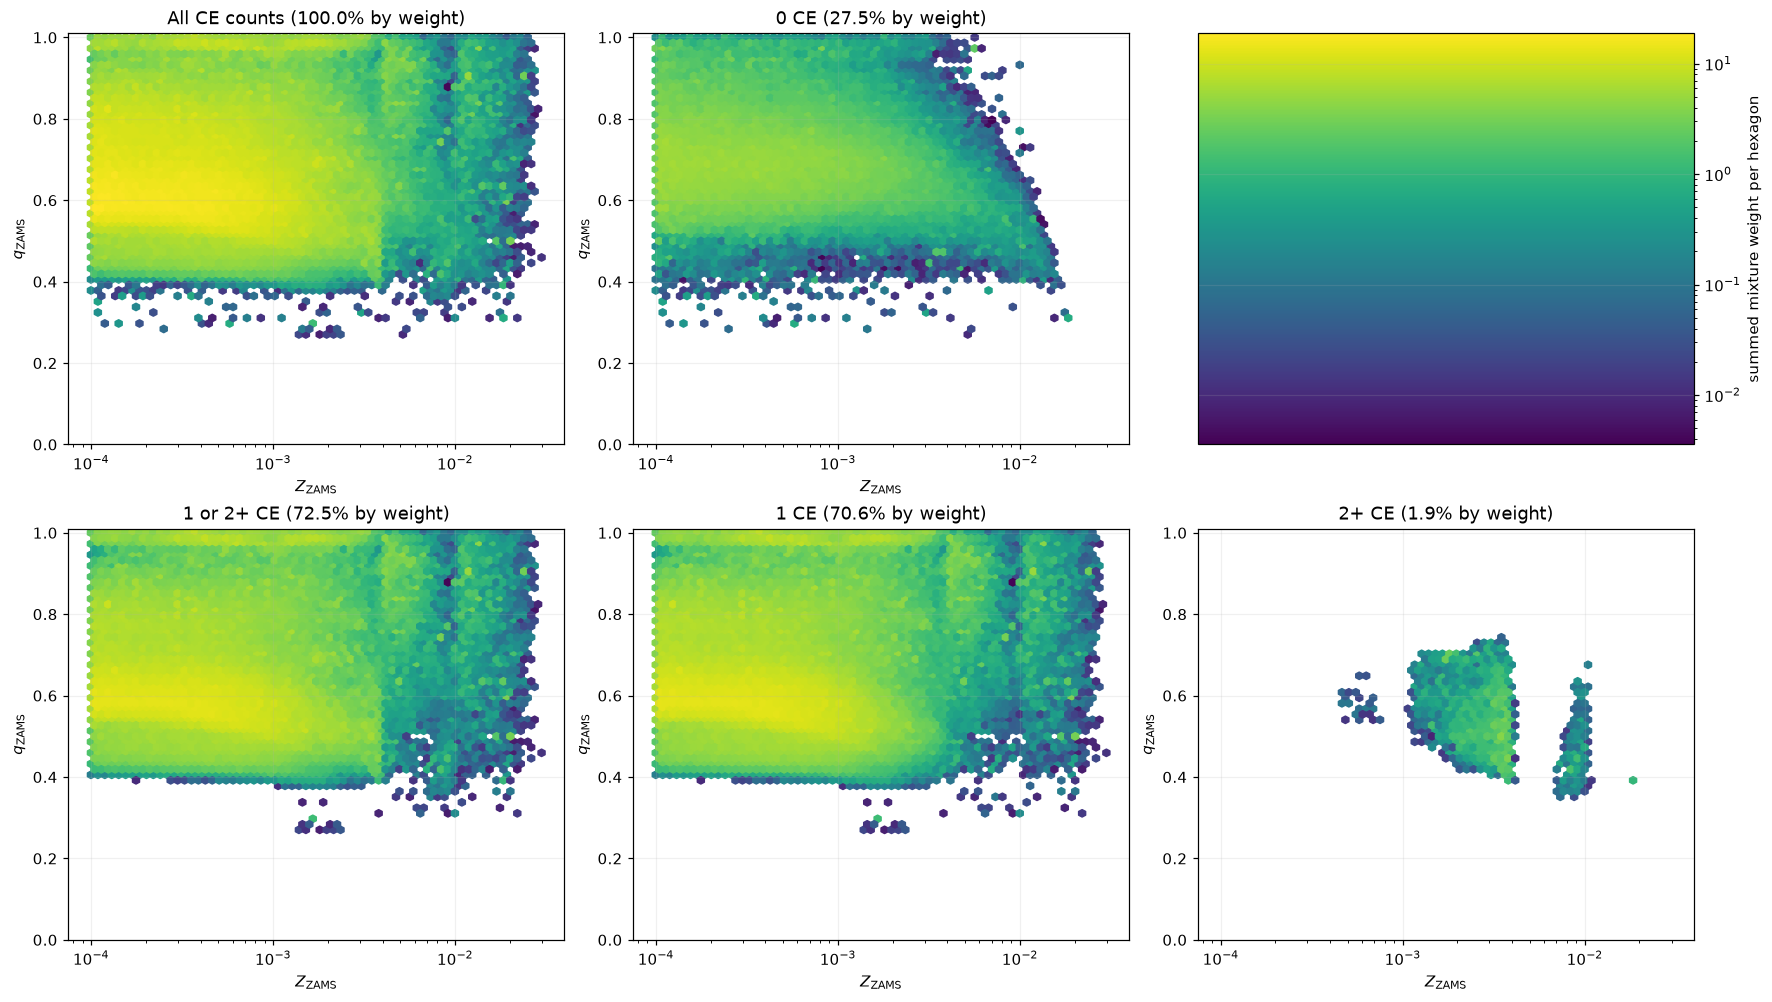

In [78]:
groups = [(merging_bbh, "All CE counts"),
          (merging_bbh.loc[merging_bbh.n_CE.eq(0)], "0 CE"),
          (merging_bbh.loc[merging_bbh.n_CE.ge(1)], "1 or 2+ CE"),
          (merging_bbh.loc[merging_bbh.n_CE.eq(1)], "1 CE"),
          (merging_bbh.loc[merging_bbh.n_CE.ge(2)], "2+ CE")]

fig = plt.figure(figsize=(16, 9), constrained_layout=True)

grid = fig.add_gridspec(2, 3)
axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1]),
        fig.add_subplot(grid[1, 0]), fig.add_subplot(grid[1, 1]),
        fig.add_subplot(grid[1, 2])]

colorbar_ax = fig.add_subplot(grid[0, 2])

hexbins = []

for ax, (group, title) in zip(axes, groups):
    h = ax.hexbin(group.Z_zams, group.q_zams, C=group.w,
                  reduce_C_function=np.sum, gridsize=65,
                  extent=(*log_Z_lim, 0, 1), xscale="log", mincnt=1, cmap="viridis")
    hexbins.append(h)
    ax.set(ylim=(0, 1.01), #xlim= Z_lim,
            xlabel=r"$Z_{\rm ZAMS}$",
           ylabel=r"$q_{\rm ZAMS}$",
           title=f"{title} ({group.w.sum()/merging_bbh.w.sum():.1%} by weight)")
    #ax.ticklabel_format(axis="x", style="plain", useOffset=False)
    #ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))

positive = np.concatenate([np.asarray(h.get_array())[np.asarray(h.get_array()) > 0]
                           for h in hexbins])
shared_norm = LogNorm(vmin=positive.min(), vmax=positive.max())

for h in hexbins:
    h.set_norm(shared_norm)

fig.colorbar(hexbins[0], cax=colorbar_ax, label="summed mixture weight per hexagon")

plt.show()

**Remarks:** The funnel shape for for `CE = 0` looks interesting, alongwith the *vertical lines*. Maybe come back to this after learning cosmic integration?

## 6. Final BBH mass plane, split by merger status

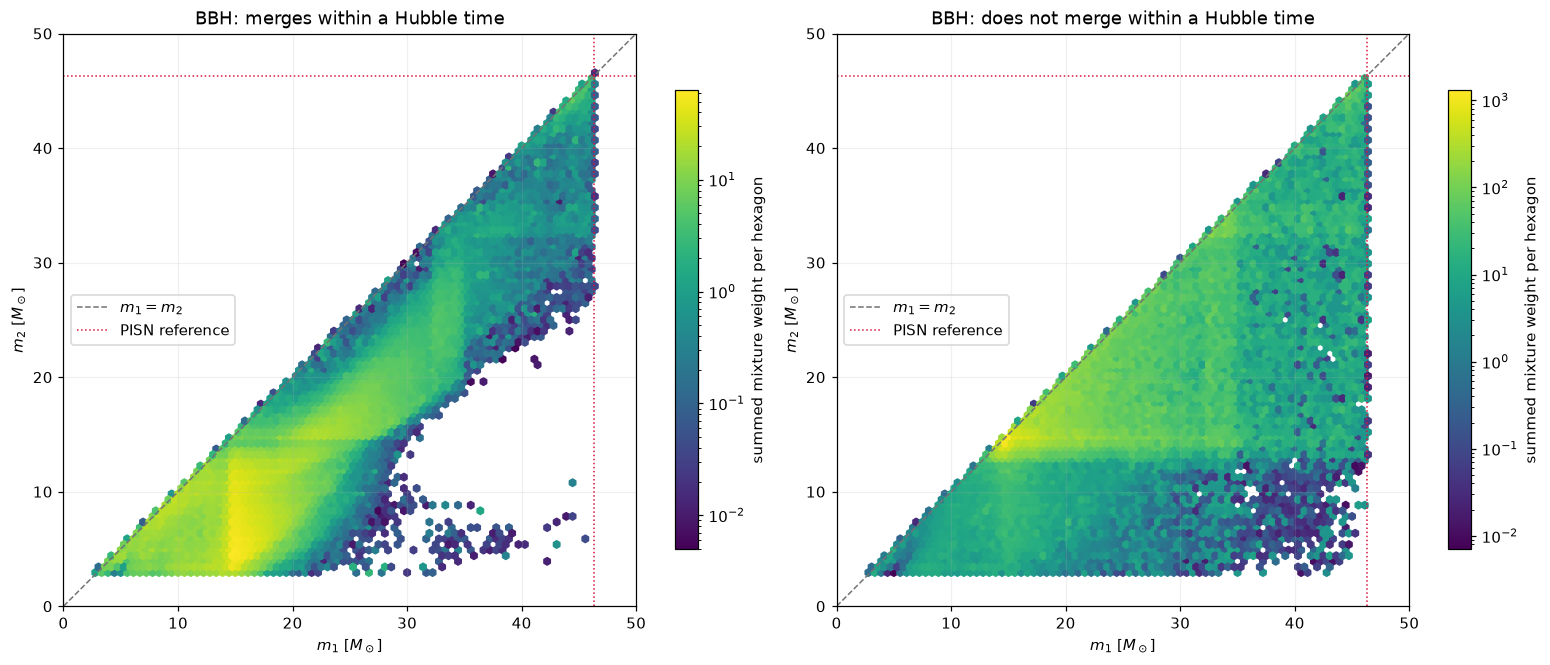

In [79]:
m_lim = merging_bbh.loc[merging_bbh.m1.lt(100), "m1"].max()

def final_mass_axes(ax, upper=50):
    ax.plot([0, upper], [0, upper], "--", c="0.45", lw=1, label=r"$m_1=m_2$")
    ax.axvline(m_lim, color="crimson", lw=1, ls=":")
    ax.axhline(m_lim, color="crimson", lw=1, ls=":", label="PISN reference")
    ax.set(xlim=(0, upper), ylim=(0, upper), aspect="equal",
           xlabel=r"$m_1$ [$M_\odot$]", ylabel=r"$m_2$ [$M_\odot$]")
    ax.legend()

def bbh_hexbin(ax, group, upper=50):
    if group.empty:
        return None
    return ax.hexbin(group.m1, group.m2, C=group.w,
                     reduce_C_function=np.sum, gridsize=90,
                     extent=(0, upper, 0, upper), mincnt=1,
                     norm=LogNorm(), cmap="viridis")

# This reproduces the original mass-plane view: 0–50 solar masses in each direction.
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
for ax, status in zip(axes, [1, 0]):
    group = dco.loc[dco.kind.eq("BBH") & dco.merges.eq(status)]
    h = bbh_hexbin(ax, group)
    final_mass_axes(ax)
    ax.set_title("BBH: merges within a Hubble time" if status else
                 "BBH: does not merge within a Hubble time")
    if h is not None:
        fig.colorbar(h, ax=ax, shrink=.75, label="summed mixture weight per hexagon")
plt.show()

## 7. Final mass plane for all three DCO types

                 rows         weight
merges kind                         
0      BBH     632826  102778.217079
       BH–NS    51737    9396.196333
       NS–NS     3414   12708.927155
1      BBH    1640550   14911.176778
       BH–NS   192673    2918.325499
       NS–NS     1922    6507.631762


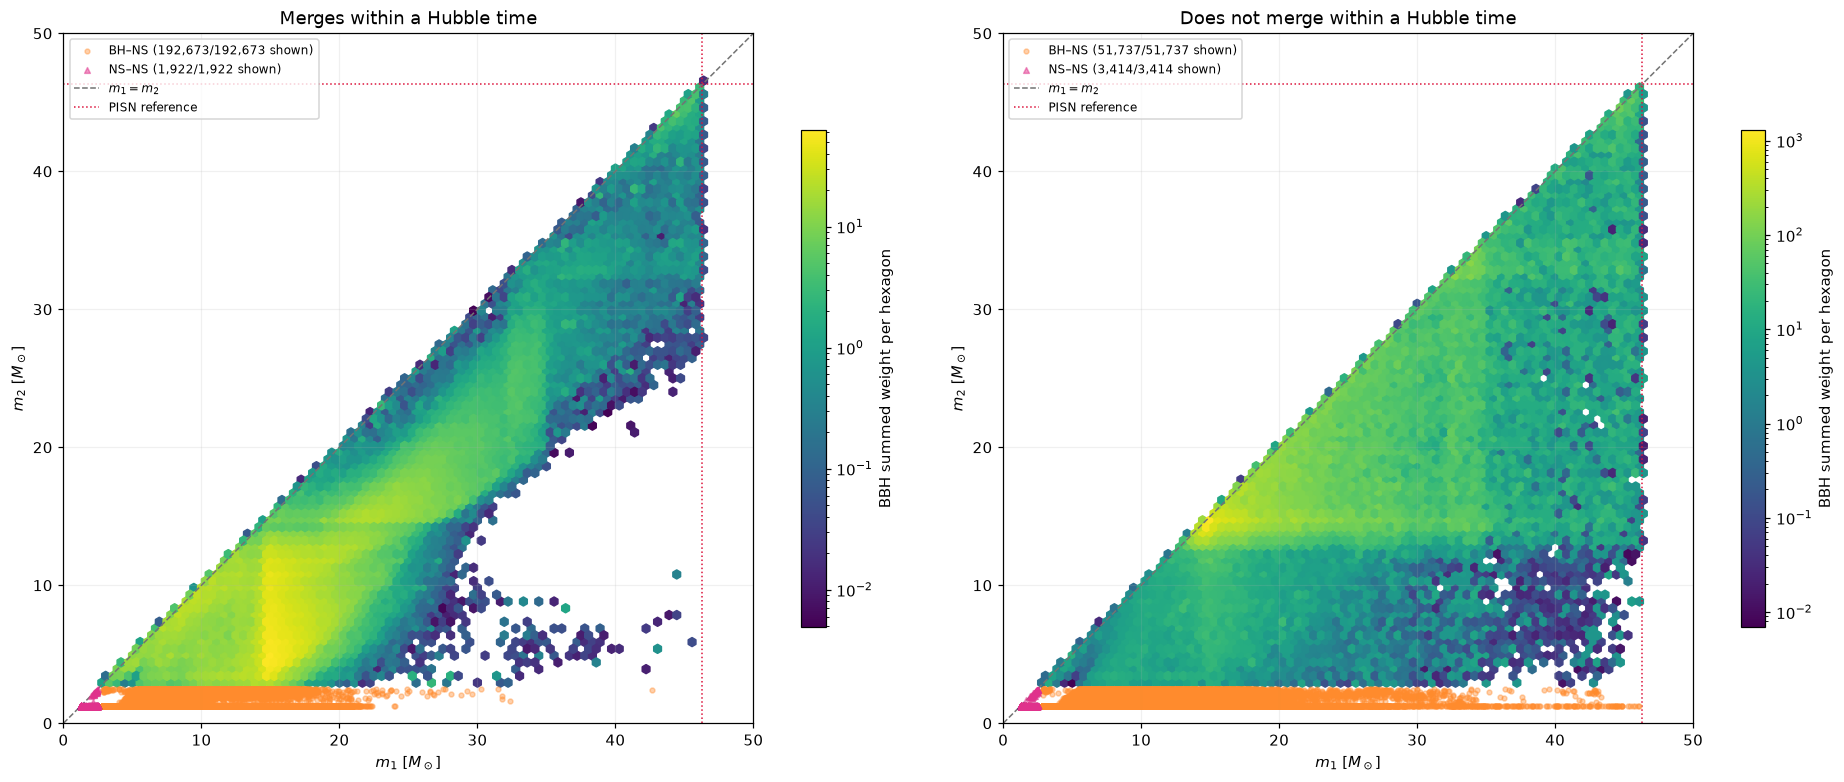

In [80]:
POINT_CAP = 200_000
point_styles = {"BH–NS": dict(color="#ff8b2d", marker="o", s=10, alpha=.4),
                "NS–NS": dict(color="#e0328c", marker="^", s=14, alpha=.5)}

def add_compact_object_points(ax, group, seed=42):
    for j, (kind, style) in enumerate(point_styles.items()):
        subset = group.loc[group.kind.eq(kind)]
        shown = subset.sample(min(len(subset), POINT_CAP), random_state=seed+j)
        ax.scatter(shown.m1, shown.m2, rasterized=True, zorder=3+j,
                   label=f"{kind} ({len(shown):,}/{len(subset):,} shown)", **style)

print(dco.groupby(["merges", "kind"]).agg(rows=("SEED", "size"),
                                           weight=("w", "sum")))
fig, axes = plt.subplots(1, 2, figsize=(17, 7), constrained_layout=True)
for ax, status in zip(axes, [1, 0]):
    group = dco.loc[dco.merges.eq(status)]
    h = bbh_hexbin(ax, group.loc[group.kind.eq("BBH")])
    add_compact_object_points(ax, group, seed=42+status)
    final_mass_axes(ax)
    ax.set_title("Merges within a Hubble time" if status else
                 "Does not merge within a Hubble time")
    ax.legend(loc="upper left", fontsize=8)
    if h is not None:
        fig.colorbar(h, ax=ax, shrink=.72, label="BBH summed weight per hexagon")
plt.show()

**Remarks:** Look into what sort of systems/formation channels givve massive BH paired with $M_{\rm NS} < 2 M_{\odot}$.


Data: [van Son et al. Zenodo record](https://doi.org/10.5281/zenodo.7612755); see companion Notebook 2 for model details and attribution.
